# Instructions on using this Calculator

In [9]:
import rasterio
import numpy as np
import pandas as pd
from rasterio.windows import Window
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import label
from skimage.transform import resize
from PIL import Image
from scipy.ndimage import generic_filter
import os

In [10]:
#Allow unlimited rows/columns in printed output
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Don't truncate horizontally
pd.set_option('display.max_colwidth', None)  # Show full column contents

## Test 1 - CDL Image Labeling

First, we define all functions and variables that we want to test

In [11]:
# Define dummy crop mapping (grayscale values to crop labels). 
CROP_TYPE_MAP = {
    0: "Out of Shapefile Bounds",
    127: "Some Crop"
}

In [12]:
#Create Majority Filter that will be used to filter out noise
def conditional_majority_filter(image, size=3):
    """Applies a majority filter only if the center pixel is the only outlier.
    
    Args:
        image (numpy array): The input image.
        size (int): The size of the filtering window (default is 3x3).
        
    Returns:
        numpy array: The filtered image.
    """
    def majority_if_outlier(values):
        center_pixel = values[len(values) // 2]  # Center pixel in the window
        surrounding_pixels = np.delete(values, len(values) // 2)  # Exclude center pixel
        
        # Check if all surrounding pixels are the same
        if np.all(surrounding_pixels == surrounding_pixels[0]) and center_pixel != surrounding_pixels[0]:
            return surrounding_pixels[0]  # Replace with majority (surrounding value)
        else:
            return center_pixel  # Keep original value

    return generic_filter(image, majority_if_outlier, size=(size, size))

In [13]:
#Uses the CROP_TYPE_MAP to apply crop labels to each pixel based on their grayscale value

def label_crops (reference_tif):
# Open the TIFF image
    with rasterio.open(reference_tif) as src:
        # Read the image data (first band)
        band = src.read(1)  # Read the first band (single-band image)

        # Get the image dimensions
        height, width = band.shape

    # Generate x and y coordinate arrays
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))

    # Flatten the arrays and create a DataFrame
    df = pd.DataFrame({
        'x': x_coords.flatten(),
        'y': y_coords.flatten(),
        'grayscale_value': band.flatten()
    })
    
    # Function to map grayscale values to crop types
    def map_crop(grayscale_value):
        return CROP_TYPE_MAP.get(grayscale_value, "Unknown")  # Default to "Unknown" if not found

    # Apply the mapping function to create the 'crop_type' column
    df['crop_type'] = df['grayscale_value'].apply(map_crop)

    # Display the first few rows of the DataFrame
    return df

In [14]:
# Function to group pixels together based on color and assign field labels (with majority filter). Adds field_id column onto existing dataframe 
def label_fields_with_filter(df: pd.DataFrame, reference_tif):
    # Open the TIFF file
    with rasterio.open(reference_tif) as ref_src:
        ref_image = ref_src.read(1)  # Read as grayscale
        ref_image = ref_image.astype(np.uint8)

    # Apply a majority filter to remove noise & prevent small pixel errors (optional step)
    ref_image = conditional_majority_filter(ref_image, size=3)    

    height, width = ref_image.shape

    # Get unique grayscale values (excluding 0 as background)
    unique_values = np.unique(ref_image)
    filtered_values = unique_values[unique_values > 0]  

    # Prepare empty field ID map
    field_labels = np.zeros_like(ref_image, dtype=np.int32)

    # Initialize field ID counter
    field_counter = 1  

    # Add field_id column to df
    df["field_id"] = 0  

    # Define 4-connectivity structure (no diagonals)
    structure_4 = np.array([[0, 1, 0],
                            [1, 1, 1],
                            [0, 1, 0]], dtype=bool)

    # Process each grayscale value separately
    for value in filtered_values:
        mask = (ref_image == value)  # Boolean mask for this grayscale value

        # Ensure we only label within this grayscale category using 4-connectivity
        labeled_regions = label(mask, structure=structure_4)[0]

        # Offset labels to ensure uniqueness across grayscale categories
        labeled_regions[labeled_regions > 0] += field_counter  

        # Ensure labels are only updated within this mask
        field_labels[mask] = labeled_regions[mask]

        # Get row and column indices where mask is True
        rows, cols = np.where(mask)

        # Extract the correct field IDs
        field_ids = labeled_regions[rows, cols]

        # Create a DataFrame mapping (y, x) to field_id
        field_update_df = pd.DataFrame({
            "y": rows,
            "x": cols,
            "field_id": field_ids
        })

        # Merge efficiently without overwriting fields incorrectly
        df = df.merge(field_update_df, on=["y", "x"], how="left", suffixes=("", "_new"))
        df["field_id"] = df["field_id_new"].fillna(df["field_id"]).astype(int)
        df.drop(columns=["field_id_new"], inplace=True)

        # Ensure next field ID does not overlap
        field_counter = field_labels.max() + 1  

    return df, field_labels

Now, we will convert our uploaded test png to a tif image to see what it looks like

In [15]:
def convert_png_to_tiff(png_filepath, tiff_filepath):
    """
    Converts a PNG image to a TIFF image.

    Args:
        png_filepath (str): The path to the input PNG file.
        tiff_filepath (str): The path to save the output TIFF file.
    """
    try:
        img = Image.open(png_filepath)
        img.save(tiff_filepath, "TIFF")
        print(f"Successfully converted '{png_filepath}' to '{tiff_filepath}'")
    except FileNotFoundError:
        print(f"Error: PNG file not found at '{png_filepath}'")
    except Exception as e:
         print(f"An error occurred: {e}")

if __name__ == "__main__":
    input_png_filename = "input.png"
    output_tiff_filename = "output.tiff"

    # Ensure the input file exists before attempting conversion
    if os.path.exists(input_png_filename):
        convert_png_to_tiff(input_png_filename, output_tiff_filename)
    else:
        print(f"Error: '{input_png_filename}' does not exist in the current directory.")

Error: 'input.png' does not exist in the current directory.


In [16]:
convert_png_to_tiff('test_tif.png', 'test_tif.tif')

Successfully converted 'test_tif.png' to 'test_tif.tif'


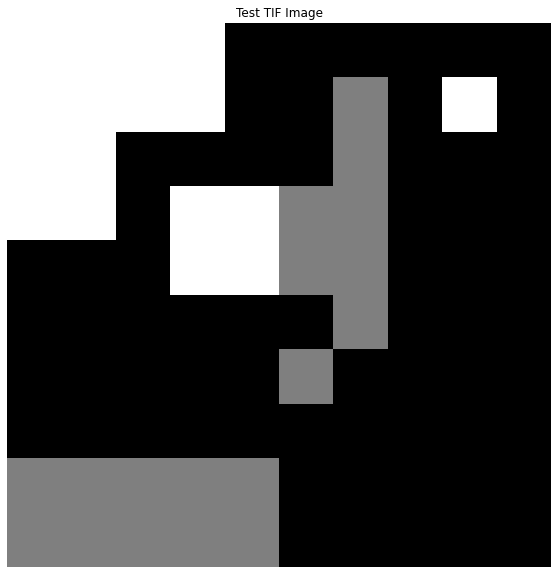

In [17]:
# Open and display the new tif image to make sure it looks right
with rasterio.open('test_tif.tif') as src:
    band = src.read(1)  # Read the first band

plt.figure(figsize=(10, 10))
plt.imshow(band, cmap='gray')  # or use 'viridis' or any other colormap
plt.title("Test TIF Image")
plt.axis("off")
plt.show()

Next, we run the tif image through the CDL processing code to make sure it produces the expected dataframe

In [18]:
#Process CDL tifs with filter (you can comment out any CDLs you are not using)
test_tif_df, test_tif_labels = label_fields_with_filter((label_crops('test_tif.tif')), 'test_tif.tif')

In [19]:
test_tif_df

,x,y,grayscale_value,crop_type,field_id
0,0,0,255,Unknown,6
1,1,0,255,Unknown,6
2,2,0,255,Unknown,6
3,3,0,255,Unknown,6
4,4,0,0,Out of Shapefile Bounds,0
5,5,0,0,Out of Shapefile Bounds,0
6,6,0,0,Out of Shapefile Bounds,0
7,7,0,0,Out of Shapefile Bounds,0
8,8,0,0,Out of Shapefile Bounds,0
9,9,0,0,Out of Shapefile Bounds,0


In [21]:
test_tif_df.to_csv('out.csv')

## Test 2 - Model Output Image Processing

First, we define the model processing functions

In [41]:
#Define function to process model output
def label_satelite_pixels(model_output_tif):
    with rasterio.open(model_output_tif) as src:
        band = src.read(1).astype(np.uint8)  # Read and convert to uint8 if needed

        # Get original dimensions
        height, width = band.shape

    # Generate x and y coordinate arrays
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))

    # Flatten and create DataFrame
    df = pd.DataFrame({
        'x': x_coords.flatten(),
        'y': y_coords.flatten(),
        'grayscale_value': band.flatten()
    })

    return df

In [42]:
# Function to group pixels together based on color and assign field labels (with no majority filter). Adds field_id column onto existing dataframe 
def process_model_output(df: pd.DataFrame, reference_tif):
    # Open the TIFF file
    with rasterio.open(reference_tif) as ref_src:
        ref_image = ref_src.read(1)  # Read as grayscale
        ref_image = ref_image.astype(np.uint8)

    # Get unique grayscale values (excluding 0 as background)
    unique_values = np.unique(ref_image)
    filtered_values = unique_values[unique_values > 0]  

    # Prepare empty field ID map
    field_labels = np.zeros_like(ref_image, dtype=np.int32)

    # Initialize field ID counter
    field_counter = 1  

    # Add field_id column to df
    df["field_id"] = 0  

    # Define 4-connectivity structure (no diagonals)
    structure_4 = np.array([[0, 1, 0],
                            [1, 1, 1],
                            [0, 1, 0]], dtype=bool)

    # Process each grayscale value separately
    for value in filtered_values:
        mask = (ref_image == value)  # Boolean mask for this grayscale value

        # Ensure we only label within this grayscale category using 4-connectivity
        labeled_regions = label(mask, structure=structure_4)[0]

        # Offset labels to ensure uniqueness across grayscale categories
        labeled_regions[labeled_regions > 0] += field_counter  

        # Ensure labels are only updated within this mask
        field_labels[mask] = labeled_regions[mask]

        # Get row and column indices where mask is True
        rows, cols = np.where(mask)

        # Extract the correct field IDs
        field_ids = labeled_regions[rows, cols]

        # Create a DataFrame mapping (y, x) to field_id
        field_update_df = pd.DataFrame({
            "y": rows,
            "x": cols,
            "field_id": field_ids
        })

        # Merge efficiently without overwriting fields incorrectly
        df = df.merge(field_update_df, on=["y", "x"], how="left", suffixes=("", "_new"))
        df["field_id"] = df["field_id_new"].fillna(df["field_id"]).astype(int)
        df.drop(columns=["field_id_new"], inplace=True)

        # Ensure next field ID does not overlap
        field_counter = field_labels.max() + 1  

    return df, field_labels

Next, we run the tif image through the model processing code to make sure it produces the expected dataframe

In [34]:
test_tif_df, test_tif_labels = process_model_output((label_satelite_pixels('test_tif.tif')), 'test_tif.tif')

/home/mayers7/.local/lib/python3.9/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [35]:
test_tif_df.to_csv('out.csv')

In [36]:
test_tif_df

,x,y,grayscale_value,field_id
0,0,0,255,6
1,1,0,255,6
2,2,0,255,6
3,3,0,255,6
4,4,0,0,0
5,5,0,0,0
6,6,0,0,0
7,7,0,0,0
8,8,0,0,0
9,9,0,0,0


## Test 3 - Field noise calculation

First, we will defline the functions and variables that we want to test

In [44]:
#this creates an array of non-crop grayscale values that we want to exclude from the calculation
exclude_grayscale_values = [0, 3, 25, 56, 57, 61, 76, 92, 111, 121, 123, 124, 131, 141, 142, 143, 152, 176, 190, 195, 219, 221, 246]

In [45]:
df_truth = df = pd.read_csv('df_truth_test.csv')
df_model_output = df = pd.read_csv('df_model_output_test.csv')

In [46]:
def compute_field_noise(df_model_output, df_truth, exclude_grayscale_values, bin_size=10): 
    # Print number of records in each DataFrame
    print(f"Records in df_model_output: {len(df_model_output)}")
    print(f"Records in df_truth: {len(df_truth)}")

    # Merge both dataframes on pixel coordinates ("x", "y")
    df_merged = df_model_output.merge(df_truth, on=["x", "y"], suffixes=("_labeled", "_truth"))

    # Determine the majority truth field per labeled field
    majority_truth = df_merged.groupby("field_id_labeled")["field_id_truth"].agg(lambda x: x.value_counts().idxmax()).reset_index()
    majority_truth.rename(columns={"field_id_truth": "majority_truth"}, inplace=True)

    # Merge majority field back into df_merged
    df_merged = df_merged.merge(majority_truth, on="field_id_labeled")

    # Get the majority grayscale value for each field_id in df_truth
    majority_grayscale = df_truth.groupby("field_id")["grayscale_value"].agg(lambda x: x.value_counts().idxmax()).reset_index()
    majority_grayscale.rename(columns={"grayscale_value": "majority_grayscale"}, inplace=True)

    # Merge this majority grayscale value onto df_merged via the majority_truth field
    df_merged = df_merged.merge(majority_grayscale, left_on="majority_truth", right_on="field_id", suffixes=("", "_gray"))

    # Now exclude only fields whose majority grayscale is in the exclusion list
    excluded_fields_by_grayscale = df_merged[df_merged["majority_grayscale"].isin(exclude_grayscale_values)]["field_id_labeled"].unique()

    # Count excluded fields due to majority grayscale value in exclusion list
    num_excluded_fields_by_grayscale = len(excluded_fields_by_grayscale)

    # Calculate field sizes (pixel count per field)
    field_sizes = df_model_output.groupby("field_id").size().reset_index(name="field_size")

    # Find 1-pixel fields
    one_pixel_fields = field_sizes[field_sizes["field_size"] == 1]["field_id"].unique()

    # Count excluded 1-pixel fields
    num_excluded_one_pixel_fields = len(one_pixel_fields)

    # Exclude both 1-pixel fields and those from grayscale exclusion
    excluded_fields = set(excluded_fields_by_grayscale) | set(one_pixel_fields)
    df_merged = df_merged[~df_merged["field_id_labeled"].isin(excluded_fields)]

    # Compute noise: pixels that do not match the majority field_id_truth
    df_merged["is_noise"] = df_merged["field_id_truth"] != df_merged["majority_truth"]

    # Compute noise score (percentage of noisy pixels per field)
    noise_scores = df_merged.groupby("field_id_labeled")["is_noise"].mean().reset_index()
    noise_scores.rename(columns={"field_id_labeled": "field_id", "is_noise": "noise_score"}, inplace=True)

    # Merge noise scores with field sizes (after filtering)
    df_noise = noise_scores.merge(field_sizes, on="field_id")

    # Assign bin labels (e.g., "1-10", "11-20", etc.)
    df_noise["field_size_bin"] = (df_noise["field_size"] // bin_size) * bin_size
    df_noise["field_size_bin"] = df_noise["field_size_bin"].astype(str) + "-" + (df_noise["field_size_bin"] + bin_size).astype(str)

    # Compute average noise score per bin and count fields in each bin
    df_avg_noise = df_noise.groupby("field_size_bin").agg(
        avg_noise_score=("noise_score", "mean"),
        field_count=("field_id", "count")
    ).reset_index()

    # Rename for clarity
    df_avg_noise.rename(columns={"field_size_bin": "field_size"}, inplace=True)

    # Sort by lower bound of field_size bin
    df_avg_noise["sort_key"] = df_avg_noise["field_size"].str.extract(r"^(\d+)", expand=False).astype(int)
    df_avg_noise = df_avg_noise.sort_values(by="sort_key").drop(columns="sort_key")

    # Print excluded pixel info
    print(f"Excluded {num_excluded_one_pixel_fields} fields with only 1 pixel.")
    print(f"Excluded {num_excluded_fields_by_grayscale} fields due to majority grayscale value being in the excluded list.")
    
    # Calculate total average noise across all fields
    total_avg_noise = df_noise["noise_score"].mean()
    print(f"Total average field noise across all fields: {total_avg_noise:.4f}")

    return df_avg_noise

Now, we run the test dataframes through the function

In [49]:
compute_field_noise(df_model_output, df_truth, exclude_grayscale_values, bin_size = 1)

Records in df_model_output: 100
Records in df_truth: 100
Excluded 1 fields with only 1 pixel.
Excluded 2 fields due to majority grayscale value being in the excluded list.
Total average field noise across all fields: 0.0361


,field_size,avg_noise_score,field_count
3,7-8,0.000000,1
4,9-10,0.000000,2
0,17-18,0.176471,1
1,19-20,0.000000,1
2,25-26,0.040000,1


## Test 4 - Pixel-Level Accuracy Calculation

First, we will defline the function and variables that we want to test

In [50]:
def compute_pixel_level_accuracy(df_model_output, df_truth, exclude_values):
    print(f"Records in df_model_output: {len(df_model_output)}")
    print(f"Records in df_truth: {len(df_truth)}")

    # Rename to avoid column collisions
    df_model_output = df_model_output.rename(columns={"field_id": "field_id_labeled"})
    df_truth = df_truth.rename(columns={"field_id": "field_id_truth"})

    # Filter out excluded grayscale values
    removed_truth = df_truth[df_truth["grayscale_value"].isin(exclude_values)]
    df_truth = df_truth[~df_truth["grayscale_value"].isin(exclude_values)]
    excluded_coords = set(zip(removed_truth["x"], removed_truth["y"]))
    df_model_output = df_model_output[~df_model_output.set_index(["x", "y"]).index.isin(excluded_coords)]

    print(f"Removed {len(removed_truth)} non-crop grayscale pixels from df_truth and {len(excluded_coords)} corresponding pixels from df_model_output.")

    # Merge on coordinates
    df_merged = df_model_output.merge(df_truth, on=["x", "y"], how="inner")

    # Step 1: Count pixels in each truth field
    field_sizes = df_truth["field_id_truth"].value_counts()
    df_merged["expected_field_size"] = df_merged["field_id_truth"].map(field_sizes)

    # Step 2: Count pixels that share the same labeled + truth field pair
    match_counts = df_merged.groupby(["field_id_labeled", "field_id_truth"]).size().reset_index(name="match_count")

    # Merge match counts back into df_merged
    df_merged = df_merged.merge(match_counts, on=["field_id_labeled", "field_id_truth"], how="left")

    # Step 3: Compute pixel-level accuracy
    # Subtract 1 to exclude the pixel itself
    df_merged["pixel_accuracy"] = (df_merged["match_count"] - 1) / (df_merged["expected_field_size"] - 1)

    # Step 4: Final accuracy
    overall_accuracy = df_merged["pixel_accuracy"].mean()

    print(f"Overall Pixel-Level Accuracy: {overall_accuracy:.2%}")

Now, we run the test dataframes through the function

In [51]:
compute_pixel_level_accuracy(df_model_output, df_truth, exclude_grayscale_values)

Records in df_model_output: 100
Records in df_truth: 100
Removed 9 non-crop grayscale pixels from df_truth and 9 corresponding pixels from df_model_output.
Overall Pixel-Level Accuracy: 77.00%
